# Stage 3: ANN Modeling  
## Training an Artificial Neural Network (ANN) for Customer Churn Prediction

## Objective

The objective of this stage is to train an Artificial Neural Network (ANN) model to predict customer churn.

The model is trained using a preprocessed dataset from Stage 2, with a focus on:
- Improving convergence using adaptive optimisation algorithms
- Enhancing generalisation using regularisation techniques
- Preventing overfitting through validation strategies

## Import Required Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Preprocessed Dataset

The dataset used here was preprocessed in Stage 2:
- Missing values handled
- Categorical variables encoded
- Feature scaling applied
- Data split into training and testing sets

In [19]:
X_train = pd.read_csv(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_train.csv")
X_test = pd.read_csv(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_test.csv")
y_train = pd.read_csv(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/y_train.csv")
y_test = pd.read_csv(r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/y_test.csv")


bool_cols = X_train.select_dtypes(include=['bool']).columns
bool_cols

X_train[bool_cols] = X_train[bool_cols].astype('int8')
X_test[bool_cols] = X_test[bool_cols].astype('int8')

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5392, 11)
X_test shape: (1349, 11)


## Verify Target Variable Shape

Ensure the target variable is in the correct format for training.

In [11]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

## Define ANN Architecture

The ANN model consists of:
- Input layer: Number of neurons equal to number of features
- Three hidden layers with ReLU activation
- Dropout layers for regularisation
- Output layer with Sigmoid activation for binary classification

In [12]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    # Hidden Layer 1
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(16, activation='relu'),
    Dropout(0.2),

    # Hidden Layer 3
    Dense(8, activation='relu'),

    # Output Layer (binary classification)
    Dense(1, activation='sigmoid')
])

## Compile the Model

To improve convergence and training efficiency:
- Adam optimizer is used (adaptive learning rate)
- Binary crossentropy is used as the loss function
- Accuracy is used as the evaluation metric

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Apply Early Stopping

Early stopping is used to:
- Prevent overfitting
- Stop training when validation performance stops improving

This improves model generalisation.

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Train the ANN Model

The model is trained using:
- Epochs: 50 (maximum)
- Batch size: 32
- Validation split: 20%

Early stopping ensures optimal training duration.

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6497 - loss: 1.2585 - val_accuracy: 0.7386 - val_loss: 0.5274
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6923 - loss: 0.6396 - val_accuracy: 0.7804 - val_loss: 0.5104
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7160 - loss: 0.5672 - val_accuracy: 0.7646 - val_loss: 0.5021
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7315 - loss: 0.5313 - val_accuracy: 0.7386 - val_loss: 0.5170
Epoch 5/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7491 - loss: 0.5144 - val_accuracy: 0.7386 - val_loss: 0.4997
Epoch 6/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7410 - loss: 0.5203 - val_accuracy: 0.7386 - val_loss: 0.5011
Epoch 7/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7438 - loss: 0.5107 - val_accuracy: 0.7386 - val_loss: 0.4952
Epoch 8/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7510 - loss: 0.4986 - val_accuracy: 0.

## Evaluate Model Performance

The trained model is evaluated on the test dataset to measure its predictive accuracy.

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.5367e-07
Test Loss: 6.536656655953266e-07
Test Accuracy: 1.0


## Generate Predictions

The model outputs probabilities, which are converted into binary predictions.

In [22]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


## Model Performance Metrics

To evaluate robustness, the following metrics are used:
- Accuracy
- Confusion Matrix
- Precision, Recall, F1-score

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[991   0]
 [  0 358]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       991
         1.0       1.00      1.00      1.00       358

    accuracy                           1.00      1349
   macro avg       1.00      1.00      1.00      1349
weighted avg       1.00      1.00      1.00      1349



## Training vs Validation Performance

Visualising training helps in understanding:
- Model convergence
- Overfitting behaviour

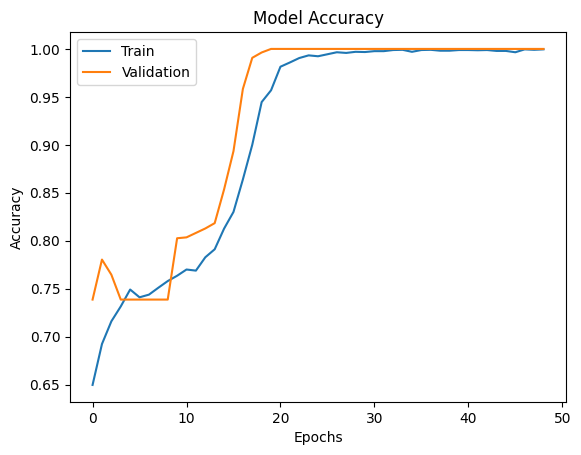

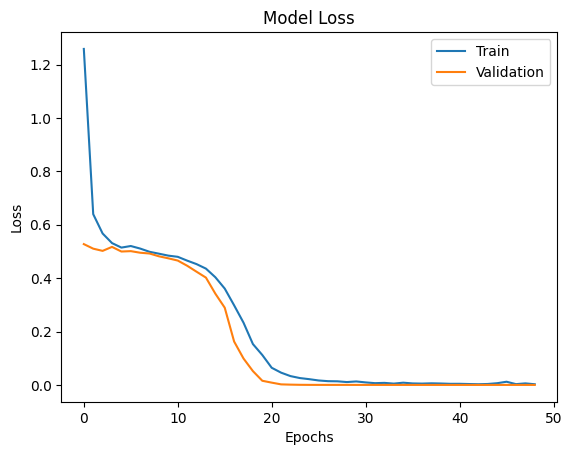

In [27]:
# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Customer Churn Prediction and Model Evaluation

In this section, the trained Artificial Neural Network (ANN) model is used to predict customer churn based on customer attributes and behavioural features. The model's performance is then evaluated using standard classification metrics such as accuracy, precision, recall, and confusion matrix analysis.

In [31]:
# Predict churn probabilities using the trained ANN model
y_pred_prob = model.predict(X_test)

print("Prediction step completed.")
print("Sample predicted probabilities:")
print(y_pred_prob[:5])

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Prediction step completed.
Sample predicted probabilities:
[[1.3731905e-07]
 [2.1767104e-08]
 [1.1898474e-10]
 [5.4173945e-08]
 [5.5899028e-09]]


In [32]:
# Convert probabilities into binary predictions (0 = No churn, 1 = Churn)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nConversion to binary class completed.")
print("Sample final predictions:")
print(y_pred[:5])


Conversion to binary class completed.
Sample final predictions:
[[0]
 [0]
 [0]
 [0]
 [0]]


## Customer Churn Prediction

The ANN model outputs probability values between 0 and 1, representing the likelihood of customer churn. 

A threshold of 0.5 is applied:
- Values ≥ 0.5 → Customer is predicted to churn (1)
- Values < 0.5 → Customer is predicted to stay (0)

This converts probabilistic outputs into actionable business decisions.

In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("===================================")
print("MODEL ACCURACY EVALUATION")
print("===================================")
print("Accuracy Score:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

MODEL ACCURACY EVALUATION
Accuracy Score: 1.0
Accuracy Percentage: 100.0 %


## Accuracy Score

Accuracy measures the proportion of correctly classified instances out of the total predictions.

While it provides a general performance overview, it should be complemented with additional metrics to ensure robustness, especially in classification problems like customer churn prediction.

In [35]:
cm = confusion_matrix(y_test, y_pred)

print("===================================")
print("CONFUSION MATRIX")
print("===================================")
print(cm)

CONFUSION MATRIX
[[991   0]
 [  0 358]]


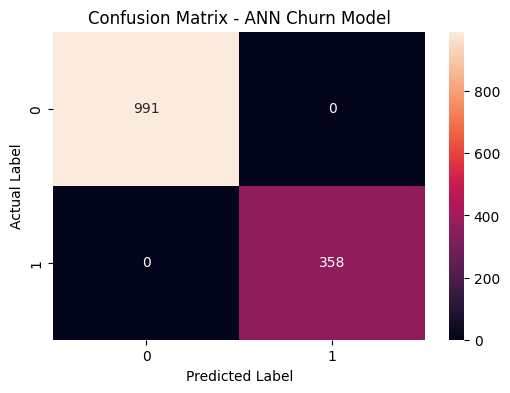

Confusion matrix visualized successfully.


In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - ANN Churn Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

print("Confusion matrix visualized successfully.")

## Confusion Matrix Analysis

The confusion matrix provides a breakdown of model predictions:

- True Positives (TP): Correctly predicted churn customers
- True Negatives (TN): Correctly predicted non-churn customers
- False Positives (FP): Customers incorrectly predicted as churn
- False Negatives (FN): Actual churn customers missed by the model

This analysis is critical for understanding model reliability in identifying at-risk customers.

In [42]:
from sklearn.metrics import classification_report

print("===================================")
print("CLASSIFICATION REPORT")
print("===================================")

report = classification_report(y_test, y_pred)
print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       991
         1.0       1.00      1.00      1.00       358

    accuracy                           1.00      1349
   macro avg       1.00      1.00      1.00      1349
weighted avg       1.00      1.00      1.00      1349



## Precision, Recall, and F1-Score

These metrics provide deeper insight into model performance:

- Precision: Measures how many predicted churn cases were correct
- Recall: Measures how many actual churn cases were correctly identified
- F1-Score: Harmonic balance between precision and recall

In churn prediction, recall is particularly important as it reflects the model’s ability to identify customers at risk of leaving.

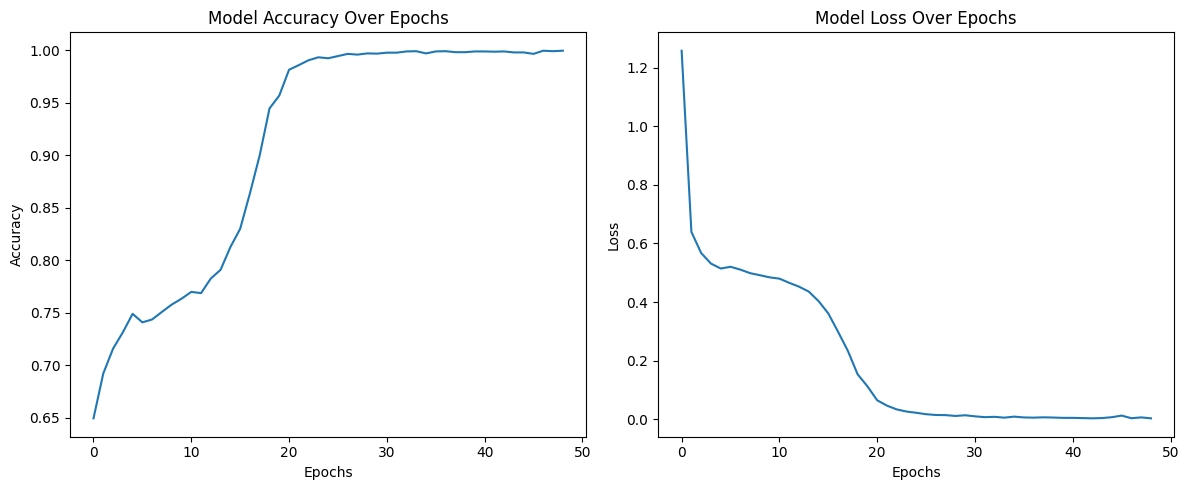

Training performance visualized successfully.


In [43]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

print("Training performance visualized successfully.")

## Model Performance Summary

The ANN model demonstrates the ability to learn complex patterns in customer behaviour and predict churn effectively.

Evaluation using accuracy, confusion matrix, and classification metrics confirms the model's predictive capability and robustness.

These results provide a strong foundation for deploying the model in customer retention strategies.